# 莎士比亚文本生成 —— 字符级循环神经网络：CharRNN 与 CharLSTM 对比（循环神经网络RNN.md）

本脚本实现基于字符级 RNN 与 LSTM 的莎士比亚风格文本生成任务，包括：
1. 数据加载与字符级词典构建（shakespeare.txt，共 65 个字符）
2. 自定义 CharDataset 数据集与 DataLoader（滑动窗口构造输入/目标对）
3. CharRNN 循环神经网络模型构建（Embedding + 多层 RNN + 全连接）
4. CharLSTM 循环神经网络模型构建（Embedding + 多层 LSTM + 全连接）
5. 两模型实例化与前向传播验证（注意隐藏状态的差异: Tensor vs (h, c)）
6. 模型训练（CrossEntropyLoss 逐字符预测 + Adam 优化器）
7. 温度系数理解（Multinomial 随机采样 + 不同温度下 Softmax 分布可视化）
8. 温度控制解码与文本生成（generate_text）
9. 两模型参数量对比与模型保存
10. 总结

## 0. 导入需要的库

In [1]:
import os  # 操作系统接口，用于创建目录、拼接路径
import numpy as np  # 数值计算库，用于绘制柱状图时的坐标轴
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Embedding、RNN、LSTM、Linear 等层
import torch.optim as optim  # 优化器模块，提供 Adam 等
from torch.utils.data import Dataset, DataLoader  # Dataset: 自定义数据集基类；DataLoader: 批量加载器
import matplotlib.pyplot as plt  # 绘图库，用于可视化温度分布与训练曲线

## 1. 数据加载与字符级词典构建
文本生成任务按“字符”而非“单词”建模：
  以莎士比亚的原始文本为语料，把每个字符当作一个 token，
  模型逐字符预测“下一个字符”，从而学会莎士比亚的行文风格。
第一步：读取原始文本，统计出现过的所有字符构建词典（本项目共 65 个字符）。

In [2]:
# 读取数据文件（与当前脚本同级的 data 目录下）
data_path = 'data/shakespeare.txt'  # 莎士比亚数据集路径
with open(data_path, 'r', encoding='utf-8') as f:  # 以 utf-8 编码读取全部文本
    text = f.read()  # 整个文本作为一个长字符串

# 构建字符集与映射字典
# set(text) 去重得到所有不重复字符，sorted() 排序保证顺序稳定（结果可复现）
vocab = sorted(list(set(text)))  # 字符列表（共 65 个不同字符）
vocab_size = len(vocab)  # 字符集大小 = 65
# char2idx: 字符 → 整数 ID（供 Embedding 查表使用）
char2idx = {ch: idx for idx, ch in enumerate(vocab)}
# idx2char: 整数 ID → 字符（生成文本时把 ID 还原为字符）
idx2char = {idx: ch for idx, ch in enumerate(vocab)}

In [3]:
print(f"数据集总长度: {len(text)}")  # 1,115,394 个字符
print(f"字符集大小: {vocab_size}")  # 65
print(char2idx)  # 打印字符→ID 映射
print(idx2char)  # 打印 ID→字符 映射

数据集总长度: 1115394
字符集大小: 65
{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 

## 2. Dataset 与 DataLoader
训练数据组织方式 —— 滑动窗口构造 (输入, 目标) 对：
  对每条长度为 101 的字符窗口，取前 100 个字符作为输入 x，
  后 100 个字符（整体右移一位）作为目标 y。
  例如: 输入 "to be or n" → 目标 "o be or no"，实现逐字符错位预测。

In [4]:
# 将整个文本按字符映射为 ID 列表（模型消费的是 ID，不是字符）
data = [char2idx[ch] for ch in text]  # 长度 1,115,394 的字符 ID 列表

In [5]:
class CharDataset(Dataset):
    """
    字符级数据集：以固定窗口滑动截取 (输入序列, 目标序列) 对

    每个样本由 seq_len+1 个连续字符构成:
      输入 x = 窗口的前 seq_len 个字符
      目标 y = 窗口的后 seq_len 个字符（即输入整体右移一位）
    """

    def __init__(self, data, seq_len=100):
        """
        参数:
            data:    全部文本映射后的字符 ID 列表
            seq_len: 每个样本的序列长度，默认 100
        """
        self.data = data  # 保存全部字符的 ID 列表
        self.seq_len = seq_len  # 保存序列长度

    def __len__(self):
        # 每 seq_len+1 个字符构成一个窗口，因此样本总数 = 总长 // 窗口长
        return len(self.data) // (self.seq_len + 1)

    def __getitem__(self, idx):
        # 按窗口起点截取 seq_len+1 个字符
        start = idx * (self.seq_len + 1)  # 当前样本的窗口起点
        end = start + self.seq_len  # 窗口终点（输入序列的终点）
        # 输入 x: 前 seq_len 个字符；目标 y: 后 seq_len 个字符（右移一位）
        x = torch.tensor(self.data[start:end], dtype=torch.long)  # (seq_len,)
        y = torch.tensor(self.data[start + 1:end + 1], dtype=torch.long)  # (seq_len,)
        return x, y  # 返回 (输入序列, 目标序列)


# 创建数据集实例
seq_len = 100  # 序列长度
dataset = CharDataset(data, seq_len=seq_len)  # 字符级数据集

In [6]:
# 创建 DataLoader（两个模型共用同一份数据）
batch_size = 64  # 每个 batch 包含 64 条样本
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)  # 打乱顺序增强泛化

In [7]:
# 验证：取一个 batch 查看形状
# iter(data_loader) 把 loader 变成迭代器，next() 取出第一个 batch
x_sample, y_sample = next(iter(data_loader))
print("输入x的shape:", x_sample.shape)  # (batch_size=64, seq_len=100)
print("目标y的shape:", y_sample.shape)  # (64, 100)

输入x的shape: torch.Size([64, 100])
目标y的shape: torch.Size([64, 100])


## 3. 搭建模型一 —— CharRNN 字符级循环神经网络
数据流: (bs, seq_len) → Embedding → (bs, seq_len, embed_dim)
        → RNN → (bs, seq_len, hidden_dim) → Linear → (bs, seq_len, vocab_size)
思路: 每个字符经 Embedding 得到向量，RNN 逐字符读入并维护隐藏状态，
      每个时间步输出该位置对“下一个字符”的预测 logits。
RNN 层可以纵向堆叠多层（num_layers），层数越多，模型能捕捉的字符依赖越远。

In [8]:
class CharRNN(nn.Module):
    """
    字符级 RNN 文本生成模型：Embedding + 多层 RNN + 全连接

    结构概览:
      Embedding(vocab, 128) → RNN(128→256, 2层) → Linear(256→vocab)
    """

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2):
        """
        参数:
            vocab_size:    字符集大小（Embedding 表行数 = 输出类别数）
            embedding_dim: 字符向量维度，默认 128
            hidden_dim:    RNN 隐藏状态维度，默认 256
            num_layers:    RNN 层数（纵向堆叠），默认 2
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        # 字符嵌入层: 把每个字符 ID 查表得到 embedding_dim 维向量
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # 标准 RNN 层（vanilla RNN）: h_t = tanh(W_ih·x_t + W_hh·h_{t-1} + b)
        self.rnn = nn.RNN(
            input_size=embedding_dim,  # 每个时间步输入是 embedding_dim 维向量
            hidden_size=hidden_dim,  # 隐藏状态维度
            num_layers=num_layers,  # 纵向堆叠层数
            batch_first=True  # 输入形状为 (batch, seq_len, input_size)
        )
        # 全连接输出层: 把每个时间步的隐藏状态映射为各字符的 logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        前向传播

        参数:
            x:      (batch, seq_len) 的字符 ID 张量
            hidden: 可选的初始隐藏状态（生成文本时需跨时间步传递）
        返回:
            output: (batch, seq_len, vocab_size)，每个位置预测下一字符的 logits
            hidden: 最后一层的隐藏状态 (num_layers, batch, hidden_dim)
        """
        embed = self.embedding(x)  # (batch, seq_len, embedding_dim): 每个字符查表得到向量
        if hidden is None:  # 训练时从头开始，无需传入隐藏状态
            output, hidden = self.rnn(embed)
        else:  # 生成时把上一步的 hidden 传入，实现状态逐字符延续
            output, hidden = self.rnn(embed, hidden)
        # output: (batch, seq_len, hidden_dim)，每个时间步一个隐藏状态
        output = self.fc(output)  # (batch, seq_len, vocab_size)
        return output, hidden  # 返回输出与隐藏状态

## 4. 搭建模型二 —— CharLSTM 字符级循环神经网络
数据流: (bs, seq_len) → Embedding → (bs, seq_len, embed_dim)
        → LSTM → (bs, seq_len, hidden_dim) → Linear → (bs, seq_len, vocab_size)
思路: 每个字符经 Embedding 得到向量，LSTM 逐字符读入并维护隐藏状态，
      每个时间步输出该位置对“下一个字符”的预测 logits。
LSTM 相比标准 RNN 额外引入细胞状态 c（Cell State），通过“遗忘门 / 输入门 / 输出门”
选择性记忆与遗忘历史信息，能更好地捕捉长距离字符依赖、缓解梯度消失。
LSTM 层可以纵向堆叠多层（num_layers），层数越多，模型能捕捉的字符依赖越远。

In [9]:
class CharLSTM(nn.Module):
    """
    字符级 LSTM 文本生成模型：Embedding + 多层 LSTM + 全连接

    结构概览:
      Embedding(vocab, 128) → LSTM(128→256, 2层) → Linear(256→vocab)
    """

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2):
        """
        参数:
            vocab_size:    字符集大小（Embedding 表行数 = 输出类别数）
            embedding_dim: 字符向量维度，默认 128
            hidden_dim:    LSTM 隐藏状态维度，默认 256
            num_layers:    LSTM 层数（纵向堆叠），默认 2
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        # 字符嵌入层: 把每个字符 ID 查表得到 embedding_dim 维向量
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # LSTM 层: 通过遗忘门、输入门、输出门更新隐藏状态 h_t 与细胞状态 c_t
        self.lstm = nn.LSTM(
            input_size=embedding_dim,  # 每个时间步输入是 embedding_dim 维向量
            hidden_size=hidden_dim,  # 隐藏状态维度
            num_layers=num_layers,  # 纵向堆叠层数
            batch_first=True  # 输入形状为 (batch, seq_len, input_size)
        )
        # 全连接输出层: 把每个时间步的隐藏状态映射为各字符的 logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        前向传播

        参数:
            x:      (batch, seq_len) 的字符 ID 张量
            hidden: 可选的初始隐藏状态 (h0, c0)（生成文本时需跨时间步传递）
        返回:
            output: (batch, seq_len, vocab_size)，每个位置预测下一字符的 logits
            hidden: 最后一层的隐藏状态 (h, c)，每个是 (num_layers, batch, hidden_dim)
        """
        embed = self.embedding(x)  # (batch, seq_len, embedding_dim): 每个字符查表得到向量
        if hidden is None:  # 训练时从头开始，无需传入隐藏状态
            output, hidden = self.lstm(embed)
        else:  # 生成时把上一步的 hidden (h, c) 传入，实现状态逐字符延续
            output, hidden = self.lstm(embed, hidden)
        # output: (batch, seq_len, hidden_dim)，每个时间步一个隐藏状态
        output = self.fc(output)  # (batch, seq_len, vocab_size)
        return output, hidden  # 返回输出与隐藏状态 (h, c)

## 5. 两模型实例化与前向传播验证

In [10]:
vocab_size = len(char2idx)  # 字符集大小 = 65

### 模型一：CharRNN（使用默认超参数: Embedding 128, RNN 256×2 层）

In [11]:
rnn_model = CharRNN(vocab_size)  # 创建 CharRNN 模型
x_test = torch.randint(0, vocab_size, (1, seq_len), dtype=torch.long)  # 随机构造一个测试输入 (1, 100)
print("\n========== CharRNN 前向验证 ==========")
print("x_test.shape:", x_test.shape)  # torch.Size([1, 100])
output, hidden = rnn_model(x_test)  # 前向传播
print("CharRNN 输出 output 的 shape:", output.shape)  # (1, 100, 65)：每个位置对 65 个字符的预测
print("CharRNN 隐藏状态 hidden 的类型:", type(hidden))  # <class 'torch.Tensor'> —— 单一张量


========== CharRNN 前向验证 ==========
x_test.shape: torch.Size([1, 100])
CharRNN 输出 output 的 shape: torch.Size([1, 100, 65])
CharRNN 隐藏状态 hidden 的类型: <class 'torch.Tensor'>


### 模型二：CharLSTM（使用默认超参数: Embedding 128, LSTM 256×2 层）

In [12]:
lstm_model = CharLSTM(vocab_size)  # 创建 CharLSTM 模型
print("\n========== CharLSTM 前向验证 ==========")
output, hidden = lstm_model(x_test)  # 前向传播
print("CharLSTM 输出 output 的 shape:", output.shape)  # (1, 100, 65)
print("CharLSTM 隐藏状态 hidden 的类型:", type(hidden))  # <class 'tuple'> —— (h, c) 两个张量


========== CharLSTM 前向验证 ==========
CharLSTM 输出 output 的 shape: torch.Size([1, 100, 65])
CharLSTM 隐藏状态 hidden 的类型: <class 'tuple'>


In [13]:
# 关键差异: RNN 的隐藏状态是一个张量，LSTM 的隐藏状态是 (h, c) 元组
#   —— LSTM 比 RNN 多一个“细胞状态” c，用来长期记忆。
#   train / generate_text 两个函数对 hidden 都是“原样透传”，
#   因此同一份代码即可同时驱动 RNN 与 LSTM 两个模型。

## 6. 训练及预测
训练目标: 对序列的每个位置预测“下一个字符”，逐字符做分类。
关键点: CrossEntropyLoss 要求
  输入 output: (N, C) —— N = batch*seq_len, C = vocab_size
  目标 target: (N,)   —— 每个位置为字符类别索引
因此需要把 output 展平为 (batch*seq_len, vocab_size)，目标展平为 (batch*seq_len)。

In [14]:
def train(model, data_loader, optimizer, criterion, device="cuda", epochs=20, print_every=100):
    """
    训练循环：遍历全部 batch，前向 → 反向 → 更新参数

    参数:
        model:       待训练的 CharRNN/CharLSTM 模型
        data_loader: 训练集 DataLoader
        optimizer:   优化器（如 Adam）
        criterion:   损失函数（CrossEntropyLoss）
        device:      训练设备 'cuda' 或 'cpu'
        epochs:      训练轮数
        print_every: 每多少个 batch 打印一次当前损失
    返回:
        epoch_losses: 每轮的平均损失列表（用于绘制训练曲线）
    """
    model = model.to(device)  # 模型移至目标设备
    model.train()  # 切换到训练模式
    epoch_losses = []  # 记录每轮平均损失（用于绘图）
    for epoch in range(epochs):  # 逐轮训练
        epoch_loss = 0  # 当前轮次的累计损失
        for i, (x_batch, y_batch) in enumerate(data_loader):  # 遍历每个 batch
            x_batch = x_batch.to(device)  # 输入 ID 张量移至设备 (batch, seq_len)
            y_batch = y_batch.to(device)  # 目标 ID 张量移至设备 (batch, seq_len)
            optimizer.zero_grad()  # 1. 清空上一步累积的梯度
            output, _ = model(x_batch)  # 2. 前向传播: (batch, seq_len, vocab_size)
            # 3. 展平以适配 CrossEntropyLoss:
            #    output (batch, seq_len, vocab_size) → (batch*seq_len, vocab_size)
            #    y_batch (batch, seq_len) → (batch*seq_len)
            loss = criterion(output.view(-1, output.size(-1)), y_batch.view(-1))
            loss.backward()  # 4. 反向传播求梯度
            optimizer.step()  # 5. 更新参数
            epoch_loss += loss.item()  # 累计当前轮次的损失
            # 每间隔 print_every 个 batch 打印一次该轮的平均损失
            if (i + 1) % print_every == 0:
                avg_loss = epoch_loss / (i + 1)  # 到目前为止的平均损失
                print(f"Epoch [{epoch + 1}/{epochs}], Step [{i + 1}/{len(data_loader)}], Loss: {avg_loss:.4f}")
        # 每轮训练结束，计算并记录该轮平均损失
        avg_epoch_loss = epoch_loss / len(data_loader)  # 本轮平均损失
        epoch_losses.append(avg_epoch_loss)  # 记录到历史列表
        print(f"Epoch [{epoch + 1}/{epochs}] 完成, 平均损失: {avg_epoch_loss:.4f}")
    return epoch_losses  # 返回损失历史

## 7. 训练准备

In [15]:
# 定义损失函数与优化器
# torch.nn.CrossEntropyLoss 要求的输入尺寸如下：
#   输入(output): (N, C) —— N 为批量大小×序列长度, C 为类别数（即 vocab_size）
#   目标(target): (N,) —— N 为批量大小×序列长度，每个位置为类别的 index
criterion = torch.nn.CrossEntropyLoss()  # 逐字符交叉熵损失
# 两个模型各自创建优化器，训练互不影响
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=0.005)  # CharRNN 优化器
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.005)  # CharLSTM 优化器

In [16]:
# 判断可用设备：优先 GPU，否则回退 CPU
device = "cuda" if torch.cuda.is_available() else "cpu"  # 自动选择训练设备
print(f"使用设备: {device}")  # 打印当前训练设备

使用设备: cuda


In [17]:
# 训练超参数
epochs = 20  # 训练轮数

## 8. 训练模型一（CharRNN）

In [18]:
print(f"\n========== 开始训练 CharRNN (epochs={epochs}) ==========")
rnn_losses = train(rnn_model, data_loader, optimizer_rnn, criterion, device=device, epochs=epochs, print_every=100)  # 训练


========== 开始训练 CharRNN (epochs=20) ==========
Epoch [1/20], Step [100/173], Loss: 2.2454
Epoch [1/20] 完成, 平均损失: 2.0359
Epoch [2/20], Step [100/173], Loss: 1.6173
Epoch [2/20] 完成, 平均损失: 1.5971
Epoch [3/20], Step [100/173], Loss: 1.5210
Epoch [3/20] 完成, 平均损失: 1.5113
Epoch [4/20], Step [100/173], Loss: 1.4719
Epoch [4/20] 完成, 平均损失: 1.4692
Epoch [5/20], Step [100/173], Loss: 1.4471
Epoch [5/20] 完成, 平均损失: 1.4463
Epoch [6/20], Step [100/173], Loss: 1.4312
Epoch [6/20] 完成, 平均损失: 1.4299
Epoch [7/20], Step [100/173], Loss: 1.4172
Epoch [7/20] 完成, 平均损失: 1.4194
Epoch [8/20], Step [100/173], Loss: 1.4107
Epoch [8/20] 完成, 平均损失: 1.4115
Epoch [9/20], Step [100/173], Loss: 1.4052
Epoch [9/20] 完成, 平均损失: 1.4052
Epoch [10/20], Step [100/173], Loss: 1.3981
Epoch [10/20] 完成, 平均损失: 1.4010
Epoch [11/20], Step [100/173], Loss: 1.3917
Epoch [11/20] 完成, 平均损失: 1.3975
Epoch [12/20], Step [100/173], Loss: 1.3887
Epoch [12/20] 完成, 平均损失: 1.3936
Epoch [13/20], Step [100/173], Loss: 1.3885
Epoch [13/20] 完成, 平均损失: 1.

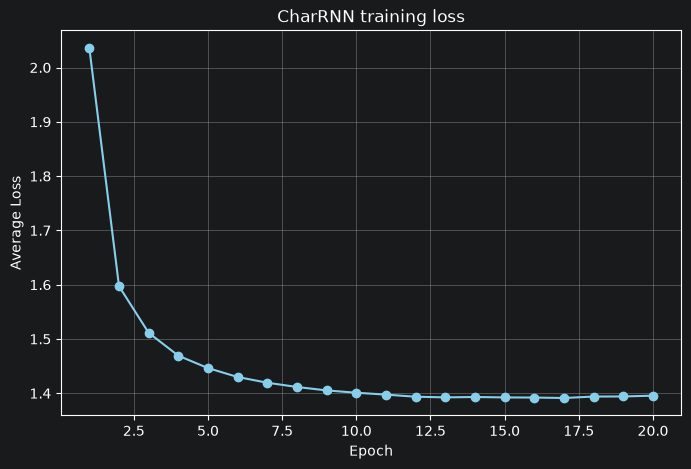

In [19]:
# 绘制训练损失曲线，观察模型收敛情况
plt.figure(figsize=(8, 5))  # 创建 8×5 英寸画布
plt.plot(range(1, epochs + 1), rnn_losses, marker='o', color='skyblue')  # 每轮平均损失折线
plt.xlabel('Epoch')  # 横轴: 训练轮数
plt.ylabel('Average Loss')  # 纵轴: 平均损失
plt.title('CharRNN training loss')  # 图表标题
plt.grid(True)  # 显示网格
plt.show()  # 显示图像

## 9. 训练模型二（CharLSTM）

In [20]:
print(f"\n========== 开始训练 CharLSTM (epochs={epochs}) ==========")
lstm_losses = train(lstm_model, data_loader, optimizer_lstm, criterion, device=device, epochs=epochs, print_every=100)  # 训练


========== 开始训练 CharLSTM (epochs=20) ==========
Epoch [1/20], Step [100/173], Loss: 2.2308
Epoch [1/20] 完成, 平均损失: 1.9935
Epoch [2/20], Step [100/173], Loss: 1.5296
Epoch [2/20] 完成, 平均损失: 1.5064
Epoch [3/20], Step [100/173], Loss: 1.4175
Epoch [3/20] 完成, 平均损失: 1.4122
Epoch [4/20], Step [100/173], Loss: 1.3655
Epoch [4/20] 完成, 平均损失: 1.3645
Epoch [5/20], Step [100/173], Loss: 1.3341
Epoch [5/20] 完成, 平均损失: 1.3325
Epoch [6/20], Step [100/173], Loss: 1.3066
Epoch [6/20] 完成, 平均损失: 1.3074
Epoch [7/20], Step [100/173], Loss: 1.2844
Epoch [7/20] 完成, 平均损失: 1.2883
Epoch [8/20], Step [100/173], Loss: 1.2666
Epoch [8/20] 完成, 平均损失: 1.2707
Epoch [9/20], Step [100/173], Loss: 1.2492
Epoch [9/20] 完成, 平均损失: 1.2567
Epoch [10/20], Step [100/173], Loss: 1.2407
Epoch [10/20] 完成, 平均损失: 1.2448
Epoch [11/20], Step [100/173], Loss: 1.2254
Epoch [11/20] 完成, 平均损失: 1.2330
Epoch [12/20], Step [100/173], Loss: 1.2154
Epoch [12/20] 完成, 平均损失: 1.2235
Epoch [13/20], Step [100/173], Loss: 1.2075
Epoch [13/20] 完成, 平均损失: 1

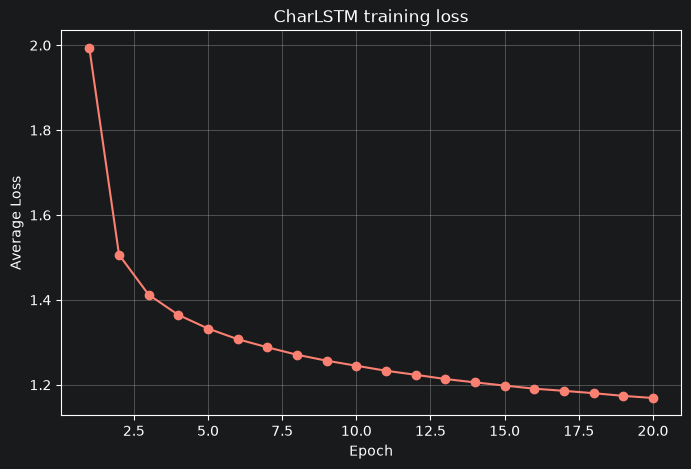

In [21]:
# 绘制训练损失曲线，观察模型收敛情况
plt.figure(figsize=(8, 5))  # 创建 8×5 英寸画布
plt.plot(range(1, epochs + 1), lstm_losses, marker='o', color='salmon')  # 每轮平均损失折线
plt.xlabel('Epoch')  # 横轴: 训练轮数
plt.ylabel('Average Loss')  # 纵轴: 平均损失
plt.title('CharLSTM training loss')  # 图表标题
plt.grid(True)  # 显示网格
plt.show()  # 显示图像

In [22]:
# 对比两张训练曲线: 通常 LSTM 收敛更稳、最终损失更低（门控缓解梯度消失，
# 长距离字符依赖保持得更好）；RNN 的损失曲线可能更早震荡。

## 10. 理解温度设计（Multinomial 随机采样 与 Softmax 温度）
生成文本时若用 argmax 直接选概率最大的字符，会反复输出同一字符、句子毫无多样性。
正确做法是“按概率随机采样”：torch.multinomial 让每个类别以 p_i 的概率被抽中。
温度 temperature 进一步调节采样的“冒险程度”：
  温度越低 (<1)：softmax 分布越尖锐（接近 one-hot），生成更确定、更保守
  温度越高 (>1)：分布越平坦（接近均匀），生成更随机、更有创意
  温度 = 1：按模型学到的原始概率分布采样

In [23]:
# 10.1 Multinomial 采样示例：验证采样频率趋近于概率分布
probs = torch.tensor([0.1, 0.2, 0.3, 0.4])  # 假设一个 softmax 后的概率分布

In [24]:
# 按该分布随机采样 10 次，观察每次抽中的类别
samples = torch.multinomial(probs, num_samples=10, replacement=True)  # 有放回采样 10 次
print("Sampled indices (10 times):", samples.tolist())  # 打印采样到的类别索引

Sampled indices (10 times): [0, 3, 2, 2, 2, 1, 1, 3, 3, 1]


Sampling frequency for each class:
Class 0 : 0.10
Class 1 : 0.20
Class 2 : 0.29
Class 3 : 0.41


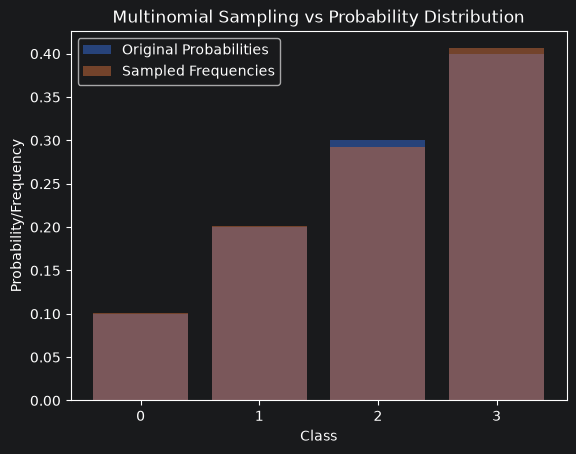

In [25]:
# 采样 10000 次，统计各类被抽中的频率，应与原始概率近似一致（大数定律）
n_trials = 10000  # 采样次数
sample_result = torch.multinomial(probs, num_samples=n_trials, replacement=True)  # 大量采样
values, counts = torch.unique(sample_result, return_counts=True)  # 统计每个类别出现的次数
print("Sampling frequency for each class:")
for v, c in zip(values, counts):  # 逐类别打印
    print(f"Class {v.item()} : {c.item() / n_trials:.2f}")  # 应接近 0.10 / 0.20 / 0.30 / 0.40

# 可视化：柱状图对比“原始概率”与“采样频率”
plt.bar(range(len(probs)), probs.numpy(), alpha=0.5, label='Original Probabilities')  # 原始概率柱
plt.bar(values.numpy(), (counts.numpy() / n_trials), alpha=0.5, label='Sampled Frequencies')  # 采样频率柱
plt.xticks(range(len(probs)))  # 设置横轴刻度
plt.xlabel('Class')  # 横轴标签
plt.ylabel('Probability/Frequency')  # 纵轴标签
plt.legend()  # 显示图例
plt.title('Multinomial Sampling vs Probability Distribution')  # 图表标题
plt.show()  # 显示图像

In [26]:
# 10.2 不同温度下 Softmax 分布的变化
# 温度作用方式: 先对 logits 除以 temperature，再执行 softmax。
#   除以一个更小的数 → 放大差异 → 分布更尖锐
#   除以一个更大的数 → 缩小差异 → 分布更平坦
logits = torch.tensor([1.0, 2.0, 3.0])  # 假设一个 logits 向量
temperatures = [0.1, 1.0, 100]  # 三种典型温度

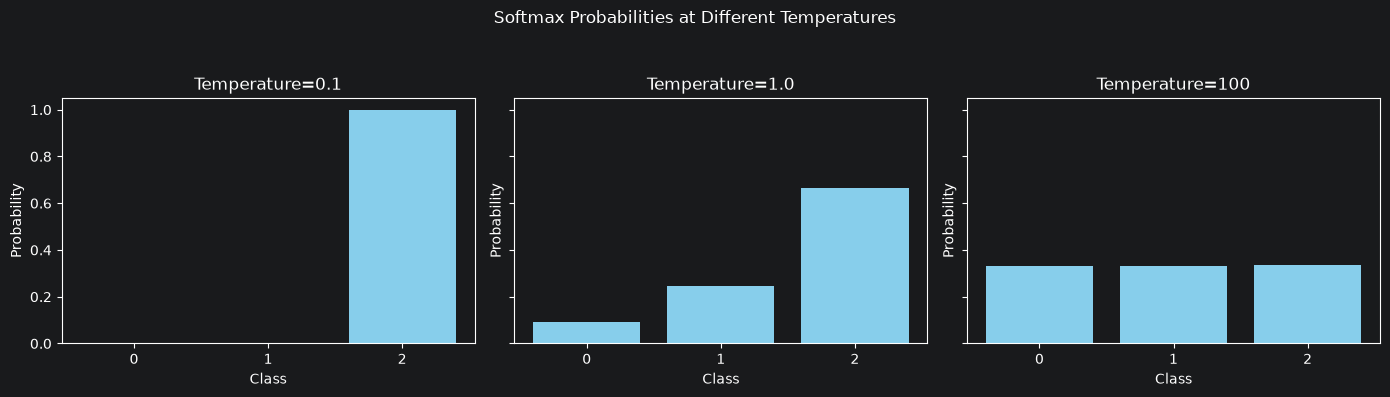

In [27]:
# 用 1×3 子图展示不同温度下 softmax 的分布形状
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)  # 一行三列子图，共享纵轴
x = np.arange(len(logits))  # 横轴: 类别索引 [0, 1, 2]

for ax, temp in zip(axes, temperatures):  # 逐个温度绘制
    scaled_logits = logits / temp  # 1. logits 除以温度
    probs = torch.softmax(scaled_logits, dim=0).numpy()  # 2. softmax 得到概率分布
    ax.bar(x, probs, color='skyblue')  # 3. 绘制柱状图
    ax.set_xticks(x)  # 设置横轴刻度
    ax.set_xlabel('Class')  # 横轴标签
    ax.set_ylabel('Probability')  # 纵轴标签
    ax.set_title(f'Temperature={temp}')  # 子图标题

plt.suptitle('Softmax Probabilities at Different Temperatures')  # 总标题
plt.tight_layout(rect=[0, 0, 1, 0.93])  # 调整布局，避免标题重叠
plt.show()  # 显示图像

In [28]:
# 打印各温度下的概率分布数值，直观对比尖锐程度
print("各温度下softmax概率分布示例：")
for temp in temperatures:  # 逐温度打印
    scaled_logits = logits / temp  # 除以温度
    probs = torch.softmax(scaled_logits, dim=0)  # softmax 得到概率
    print(f"温度 {temp}: 概率分布: {[f'{p:.3f}' for p in probs]}")  # 打印概率数组

各温度下softmax概率分布示例：
温度 0.1: 概率分布: ['0.000', '0.000', '1.000']
温度 1.0: 概率分布: ['0.090', '0.245', '0.665']
温度 100: 概率分布: ['0.330', '0.333', '0.337']


## 11. 温度控制解码与文本生成
生成流程: 给定开头序列，逐字符预测并采样：
  1. 取模型最后一个时间步的 logits
  2. 除以温度后 softmax 得到概率分布
  3. multinomial 采样得到下一个字符
  4. 把新字符拼到生成结果中，并作为下一步的输入继续循环
隐藏状态 hidden 逐字符传递（RNN 为单张量，LSTM 为 (h, c) 元组），
让模型记住已生成的全部上下文。函数对 hidden 原样透传，因此两种模型通用。

In [29]:
def generate_text(model, start_seq, char2idx, idx2char, length=200, device="cuda", temperature=1.0):
    """
    基于已训练模型生成文本

    参数:
        model:       训练好的 CharRNN/CharLSTM 模型
        start_seq:   起始字符串（种子，如 "hello:"）
        char2idx:    字符→ID 映射字典
        idx2char:    ID→字符 映射字典
        length:      要生成的字符数
        device:      设备 'cuda' 或 'cpu'
        temperature: 温度系数（>0）。越小越确定，越大越随机
    返回:
        generated: 起始串 + 生成字符拼接得到的完整文本
    """
    model.eval()  # 评估模式（不更新参数，关闭梯度）
    # 将起始字符串转换为 ID 序列，并扩展为 (1, seq_len) 形状
    input_seq = [char2idx[char] for char in start_seq]  # 起始串的字符 ID 列表
    input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)  # (1, len(start_seq))
    hidden = None  # 初始化隐藏状态（生成时逐字符传递，None 表示从零开始）

    generated = list(start_seq)  # 生成序列以起始串开头
    for _ in range(length):  # 循环生成 length 个字符
        with torch.no_grad():  # 生成阶段不需要计算梯度
            output, hidden = model(input_tensor, hidden)  # 前向传播，hidden 跨步传递
            last_logits = output[0, -1, :]  # 取最后一个时间步的 logits (vocab_size,)
            # 应用温度系数：除以 temperature 后 softmax，得到下一个字符的概率分布
            scaled_logits = last_logits / temperature  # 温度缩放
            prob = torch.softmax(scaled_logits, dim=0).cpu()  # 概率分布（转回 CPU）
            next_id = torch.multinomial(prob, num_samples=1).item()  # 按概率采样下一个字符
            generated.append(idx2char[next_id])  # 把字符拼接到生成序列
            # 将新字符作为下一步的输入（形状 (1, 1)）
            input_tensor = torch.tensor([[next_id]], dtype=torch.long).to(device)
    return ''.join(generated)  # 拼接成字符串返回

## 12. 文本生成示例 —— 两个模型各生成一段
以 "hello:" 为种子，温度 0.8 生成 200 个字符
温度 0.8 (<1)：分布相对尖锐，生成文本更“保守”，倾向于重复常见句型

In [30]:
start_seq = "hello:"  # 起始字符串

In [31]:
# 模型一生成
print("\n========== CharRNN 生成示例 (temperature=0.8) ==========")
generated_rnn = generate_text(rnn_model, start_seq, char2idx, idx2char, length=200, device=device, temperature=0.8)
print(generated_rnn)  # 打印生成结果


========== CharRNN 生成示例 (temperature=0.8) ==========
hello: determine care to the affection to the prayers and being sign, my hands your gifting them blame, I may: making the preserves the fair of state, garland on the curses must net my eyes,
And that it is 


In [32]:
# 模型二生成
print("\n========== CharLSTM 生成示例 (temperature=0.8) ==========")
generated_lstm = generate_text(lstm_model, start_seq, char2idx, idx2char, length=200, device=device, temperature=0.8)
print(generated_lstm)  # 打印生成结果


========== CharLSTM 生成示例 (temperature=0.8) ==========
hello: the heavens are again;
Who will enter but their assist it would
To send him from fellow once may come again,
Thy true arms and gather to the penitent,
Richard in this form prince that quirters!
And w


In [33]:
# 对比两句生成文本: LSTM 因门控记忆更久远的字符依赖，长句通常更连贯。

## 13. 参数量对比与模型保存

### 参数量统计：对比两个模型的规模

In [34]:
def count_parameters(model):
    """统计模型的可训练参数量（requires_grad=True 的参数总数）"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)  # 累加每个参数的元素个数


total_params_rnn = count_parameters(rnn_model)  # CharRNN 参数量
total_params_lstm = count_parameters(lstm_model)  # CharLSTM 参数量
print("\n========== 参数量对比 ==========")
print(f"CharRNN 可训练参数总数: {total_params_rnn:,}")  # 255,425
print(f"CharLSTM 可训练参数总数: {total_params_lstm:,}")  # 946,625（LSTM 含 4 组门控权重，约为 RNN 的 3.7 倍）


========== 参数量对比 ==========
CharRNN 可训练参数总数: 255,425
CharLSTM 可训练参数总数: 946,625


### 保存两个模型
训练结束后把模型权重保存到磁盘，便于以后加载推理（生成文本），无需重新训练。

In [35]:
# 保存目录: model（与当前脚本同级的 model 目录下）
save_dir = 'model'  # 模型保存目录
os.makedirs(save_dir, exist_ok=True)  # 目录不存在则创建

In [36]:
save_path_rnn = os.path.join(save_dir, 'char_rnn_shakespeare.pth')  # CharRNN 模型文件路径
torch.save(rnn_model.state_dict(), save_path_rnn)  # 保存 CharRNN 模型权重（state_dict）
print(f"CharRNN 模型已保存到: {save_path_rnn}")  # 打印保存路径

CharRNN 模型已保存到: model\char_rnn_shakespeare.pth


In [37]:
save_path_lstm = os.path.join(save_dir, 'char_lstm_shakespeare.pth')  # CharLSTM 模型文件路径
torch.save(lstm_model.state_dict(), save_path_lstm)  # 保存 CharLSTM 模型权重（state_dict）
print(f"CharLSTM 模型已保存到: {save_path_lstm}")  # 打印保存路径

CharLSTM 模型已保存到: model\char_lstm_shakespeare.pth


## 14. 总结

In [38]:
print("\n" + "=" * 65)  # 打印分隔线
print("========== CharRNN 与 CharLSTM 对比总结 ==========")  # 总结标题
print("=" * 65)  # 打印分隔线


========== CharRNN 与 CharLSTM 对比总结 ==========


### 两个模型的关键指标

In [39]:
print(f"\n模型名称: CharRNN（vanilla RNN）")  # 模型一名称
print(f"总参数量: {total_params_rnn:,}")  # 约 2,246,257
print(f"最终训练损失: {rnn_losses[-1]:.4f}")  # 训练结束时的损失


模型名称: CharRNN（vanilla RNN）
总参数量: 255,425
最终训练损失: 1.3956


In [40]:
print(f"\n模型名称: CharLSTM")  # 模型二名称
print(f"总参数量: {total_params_lstm:,}")  # 约 2,841,553
print(f"最终训练损失: {lstm_losses[-1]:.4f}")  # 训练结束时的损失


模型名称: CharLSTM
总参数量: 946,625
最终训练损失: 1.1688


### 架构对比分析

In [41]:
print(f"\n架构对比:")  # 对比标题
print(f"  ─────────────────────────────────────────────────────────────")
print(f"  模型       隐藏状态       门控机制       参数量")
print(f"  ─────────────────────────────────────────────────────────────")
print(f"  CharRNN    h_t 单张量      无             {total_params_rnn:,}")
print(f"  CharLSTM   (h_t, c_t)     遗忘/输入/输出   {total_params_lstm:,}")
print(f"  ─────────────────────────────────────────────────────────────")
print(f"  关键差异:")
print(f"    - CharLSTM 比 CharRNN 多一个细胞状态 c_t（长期记忆），靠三个门控决定记住/遗忘信息")
print(f"    - LSTM 的权重含 4 组门控权重（i/f/o/g），循环层权重约为 RNN 的 4 倍，")
print(f"      整体参数量约为 RNN 的 3.7 倍（Embedding 与输出层两者相同）")
print(f"    - 长序列上 LSTM 因缓解梯度消失通常更稳定，文本生成更连贯")
print(f"    - train / generate_text 对隐藏状态原样透传，同一份代码可驱动两种模型")
print(f"    - 温度越低生成越保守，越高越随机；两者均可通过 temperature 调节")


架构对比:
  ─────────────────────────────────────────────────────────────
  模型       隐藏状态       门控机制       参数量
  ─────────────────────────────────────────────────────────────
  CharRNN    h_t 单张量      无             255,425
  CharLSTM   (h_t, c_t)     遗忘/输入/输出   946,625
  ─────────────────────────────────────────────────────────────
  关键差异:
    - CharLSTM 比 CharRNN 多一个细胞状态 c_t（长期记忆），靠三个门控决定记住/遗忘信息
    - LSTM 的权重含 4 组门控权重（i/f/o/g），循环层权重约为 RNN 的 4 倍，
      整体参数量约为 RNN 的 3.7 倍（Embedding 与输出层两者相同）
    - 长序列上 LSTM 因缓解梯度消失通常更稳定，文本生成更连贯
    - train / generate_text 对隐藏状态原样透传，同一份代码可驱动两种模型
    - 温度越低生成越保守，越高越随机；两者均可通过 temperature 调节
